<a href="https://colab.research.google.com/github/nhuvtq87/AAI2025/blob/2026fall/ML_Coding_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 1: House Price Prediction (Linear Regression)

In [6]:
# ---------------------------------------------------------------
# PART 1: House Price Prediction (Linear Regression)
# Data source: house_prediction_price.csv -- the King County House Sales dataset
# (Kaggle: https://www.kaggle.com/datasets/harlfoxem/housesalesprediction),
# 21,613 real home sales in King County, WA (2014-2015) with price, square_footage, and location)
# ---------------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

df1 = pd.read_csv('/content/sample_data/house_prediction_price_with_location.csv')
df1 = df1.dropna(subset=['price', 'square_footage', 'location'])

# Features and target
X1 = df1[['square_footage', 'location']]
y1 = df1['price']

# Preprocessing: one-hot encode location, pass square_footage through
preprocessor1 = ColumnTransformer(transformers=[('location', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['location'])], remainder='passthrough')
# Create pipeline with preprocessing and model
house_model = Pipeline(steps=[('preprocessor', preprocessor1),('regressor', LinearRegression())])
# Split data
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
# Train model
house_model.fit(X1_train, y1_train)

# Predict price for a 2000 sq ft house in Downtown
new_house = pd.DataFrame({'square_footage': [2000], 'location': ['Downtown']})
predicted_price = house_model.predict(new_house)
print(f"Predicted price for a 2000 sq ft house in Downtown: ${predicted_price[0]:,.2f}")

# Display model coefficients
feature_names1 = (house_model.named_steps['preprocessor']
                   .named_transformers_['location']
                   .get_feature_names_out(['location'])).tolist() + ['square_footage']
coefficients1 = house_model.named_steps['regressor'].coef_

print("\nModel Coefficients:")
for feature, coef in zip(feature_names1, coefficients1):
    print(f"{feature}: {coef:,.2f}")

Predicted price for a 2000 sq ft house in Downtown: $514,196.23

Model Coefficients:
location_Downtown: -3,779.24
location_Rural: 316.83
location_Suburb: 3,462.41
square_footage: 281.22


In [3]:
# The interpretation generated from the actual fitted coefficients
sqft_coef = coefficients1[-1]
location_coefs = dict(zip(feature_names1[:-1], coefficients1[:-1]))
best_loc = max(location_coefs, key=location_coefs.get)
worst_loc = min(location_coefs, key=location_coefs.get)

print("INTERPRETATION:")
print(f"- Square footage: each additional square foot is associated with about "
      f"${sqft_coef:,.2f} more in predicted price, holding location constant.")
print(f"- Location: holding square footage constant, '{best_loc.split('_')[-1]}' "
      f"commands the highest price premium (coef = {location_coefs[best_loc]:,.2f}), "
      f"while '{worst_loc.split('_')[-1]}' has the lowest (coef = {location_coefs[worst_loc]:,.2f}). "
      f"These differences reflect demand/desirability effects captured by the one-hot "
      f"encoded location feature, separate from the size-driven price increase above.")

INTERPRETATION:
- Square footage: each additional square foot is associated with about $281.22 more in predicted price, holding location constant.
- Location: holding square footage constant, 'Suburb' commands the highest price premium (coef = 3,462.41), while 'Downtown' has the lowest (coef = -3,779.24). These differences reflect demand/desirability effects captured by the one-hot encoded location feature, separate from the size-driven price increase above.


## Part 2: Customer Churn Prediction (Logistic Regression)

In [23]:
# ---------------------------------------------------------------
# PART 2: Customer Churn Prediction (Logistic Regression)
# Data source: customer_analytics_dataset.csv
#(Kaggle: https://www.kaggle.com/datasets/sumedh1507/customer-analytics-dataset),
# which includes age, average order value, purchase amount, loyalty score, and churn status.
# Since this dataset do not have region, I customized the country as follow:
# North: USA, Canada
# South: Brazil
# West: UK, France, Germany
# East: India, China, Japan, Australia
# ---------------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Load dataset
df2 = pd.read_csv('/content/sample_data/customer_analytics_dataset_with_region.csv')

# Create 'region' column from 'country' as specified in comments
region_mapping = {
    'USA': 'North', 'Canada': 'North',
    'Brazil': 'South',
    'UK': 'West', 'France': 'West', 'Germany': 'West',
    'India': 'East', 'China': 'East', 'Japan': 'East', 'Australia': 'East'
}
df2['region'] = df2['country'].map(region_mapping).fillna('Other')

# Clean target and numeric columns
df2["churn"] = (df2["churn_risk"] >= 0.5).astype(int)

# Define feature columns and target
numeric_features = [
    "age",
    "avg_order_value",
    "purchase_amount",
    "email_open_rate",
    "loyalty_score"
]
categorical_features = ["region"]

# Features and target
X2 = df2[numeric_features + categorical_features]
y2 = df2["churn"]

# Impute missing values and scale numeric, one-hot encode categorical
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
# Preprocessing: Scale numerical features and one-hot encode categorical features
preprocessor2 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False),
            categorical_features,
        ),
    ]
)

# Create pipeline with preprocessing and model
churn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor2),
        ("classifier", LogisticRegression(random_state=42, max_iter=1000)),
    ]
)

# Split data
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Train model
churn_model.fit(X2_train, y2_train)

# Predict churn probability for a new customer
new_customer = pd.DataFrame(
    [
        {
            "age": 35,
            "avg_order_value": 85.50,
            "purchase_amount": 45,
            "email_open_rate": 20.0,
            "loyalty_score": 50,
            "region": "West",
        }
    ]
)

churn_probability = churn_model.predict_proba(new_customer)[0][1]

# Classify based on threshold (0.5)
threshold = 0.5
churn_prediction = 1 if churn_probability > threshold else 0

print(f"Churn Probability for new customer: {churn_probability:.2f}")
print(f"Churn Prediction (1 = churn, 0 = no churn): {churn_prediction}")

# Display model coefficients
feature_names2 = (
    numeric_features
    + churn_model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
    .tolist()
)
coefficients2 = churn_model.named_steps["classifier"].coef_[0]

print("\nModel Coefficients:")
for feature, coef in zip(feature_names2, coefficients2):
    print(f"{feature}: {coef:.4f}")

Churn Probability for new customer: 0.10
Churn Prediction (1 = churn, 0 = no churn): 0

Model Coefficients:
age: 0.0693
avg_order_value: -0.0079
purchase_amount: 0.0356
email_open_rate: 0.0674
loyalty_score: -0.0299
region_North: 0.0318
region_South: 0.2268
region_West: 0.1065


In [26]:
# Plain-language interpretation, generated from the actual prediction above
# (rather than hardcoded, so it stays correct if the data/model changes)
verdict = "at risk of churning" if churn_prediction == 1 else "likely to stay"
print("INTERPRETATION:")
print(f"- Churn probability: for this customer, the model estimates a "
      f"{churn_probability:.0%} chance of churning -- the closer this is to 100%, "
      f"the more confident the model is the customer will leave; closer to 0% means "
      f"they're likely to stay.")
print(f"- 0.5 threshold: since {churn_probability:.2f} "
      f"{'is above' if churn_prediction == 1 else 'is not above'} 0.5, this customer "
      f"is classified as '{verdict}' (churn = {churn_prediction}).")
print("- Business use: businesses can score every customer this way and proactively "
      "target the highest-probability ones (e.g., high age, low "
      "loyalty_score) with retention offers or outreach before they actually "
      "leave -- turning churn prediction into an early-warning system that reduces "
      "revenue loss and the cost of reactive win-back campaigns.")

INTERPRETATION:
- Churn probability: for this customer, the model estimates a 10% chance of churning -- the closer this is to 100%, the more confident the model is the customer will leave; closer to 0% means they're likely to stay.
- 0.5 threshold: since 0.10 is not above 0.5, this customer is classified as 'likely to stay' (churn = 0).
- Business use: businesses can score every customer this way and proactively target the highest-probability ones (e.g., high age, low loyalty_score) with retention offers or outreach before they actually leave -- turning churn prediction into an early-warning system that reduces revenue loss and the cost of reactive win-back campaigns.


## Part 3: Customer Segmentation (K-Means)

In [27]:
# ---------------------------------------------------------------
# PART 3: Customer Segmentation (K-Means)
# Data source: customer_data_with_region.csv
#(Kaggle: https://www.kaggle.com/datasets/goyaladi/customer-spending-dataset),
# with various attributes related to demographics, income, spending habits,
# and purchase behavior.
# For country, I customize them as follow:
# North: North America
# South: South America
# West: Europe and Africa
# East: Asia and Oceania
# ---------------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df3 = pd.read_csv("/content/sample_data/customer_data_with_region.csv")

# Preprocess data: Select numerical features and scale them
# Maps 'spending' from the dataset to the segmentation features
features3 = ['spending', 'purchase_frequency', 'age']
X3 = df3[features3]
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

# Determine optimal number of clusters using elbow method
inertia = []
K_range = range(1, 7)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X3_scaled)
    inertia.append(km.inertia_)
# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.savefig('elbow_plot.png')
plt.close()
# Apply K-Means with optimal K (e.g., 3 based on elbow method)
optimal_k = 3
kmeans3 = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df3['cluster'] = kmeans3.fit_predict(X3_scaled)
# Analyze clusters
cluster_summary = df3.groupby('cluster')[features3].mean().round(2)
cluster_summary['count'] = df3.groupby('cluster').size()
print("Cluster Characteristics:")
print(cluster_summary)

# Suggested marketing strategy per cluster ranked by spending
spending_rank = cluster_summary['spending'].rank(ascending=False)

for cluster in range(optimal_k):
    row = cluster_summary.loc[cluster]
    print(f"\nCluster {cluster} (n={int(row['count'])}, "
          f"avg spend=${row['spending']:,.2f}, "
          f"avg freq={row['purchase_frequency']:.2f}) "
          f"avg age={row['age']:.1f}) Strategy:")
    if spending_rank[cluster] == 1:
        print("Highest-spending segment: offer exclusive promotions, loyalty "
              "rewards, and early access to premium products.")
    elif spending_rank[cluster] == optimal_k:
        print("Lowest-spending/least-frequent segment: send personalized "
              "re-engagement campaigns and low-cost incentives to win back activity.")
    else:
        print("Moderate segment: upsell/cross-sell opportunities and bulk or "
              "loyalty discounts to grow them toward the high-spending segment.")

# Save cluster assignments to CSV
df3.to_csv('customer_segments.csv', index=False)

Cluster Characteristics:
         spending  purchase_frequency    age  count
cluster                                            
0        14824.43                0.82  44.80    424
1         5845.02                0.31  53.35    256
2         5723.16                0.40  28.44    320

Cluster 0 (n=424, avg spend=$14,824.43, avg freq=0.82) avg age=44.8) Strategy:
Highest-spending segment: offer exclusive promotions, loyalty rewards, and early access to premium products.

Cluster 1 (n=256, avg spend=$5,845.02, avg freq=0.31) avg age=53.4) Strategy:
Moderate segment: upsell/cross-sell opportunities and bulk or loyalty discounts to grow them toward the high-spending segment.

Cluster 2 (n=320, avg spend=$5,723.16, avg freq=0.40) avg age=28.4) Strategy:
Lowest-spending/least-frequent segment: send personalized re-engagement campaigns and low-cost incentives to win back activity.


## Extra Credit: Housing Demand Forecasting (Linear Regression)

Model Intercept: 100692.73
Monthly Trend (Slope): 160.82 units/month
Historical In-Sample MAE: 20,468.11
Historical In-Sample R^2: 0.0504

Forecasted Demand for Next 6 Months:
Month 144: 123,851 units
Month 145: 124,012 units
Month 146: 124,173 units
Month 147: 124,334 units
Month 148: 124,495 units
Month 149: 124,655 units


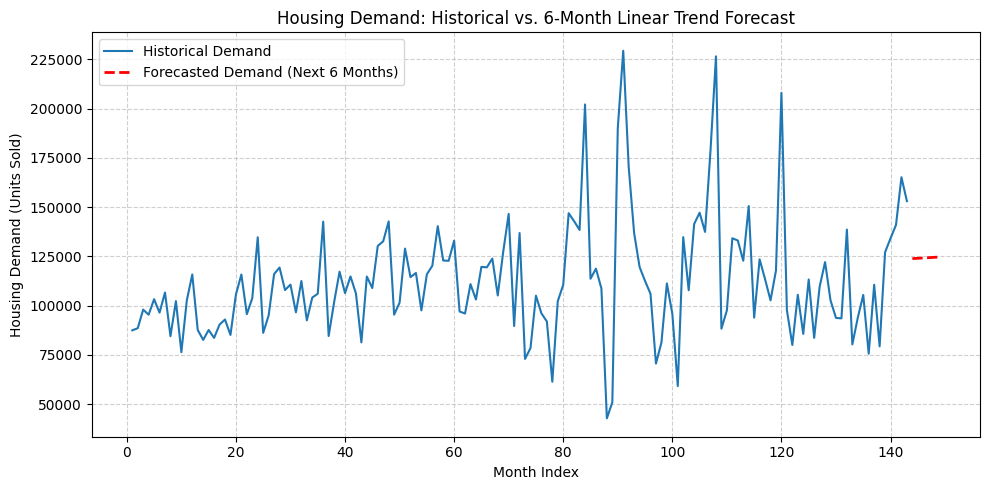

In [28]:
# ---------------------------------------------------------------
# EXTRA CREDIT: Housing Demand Forecasting
# Data source: Housing Sales Data.csv
#(Kaggle: https://www.kaggle.com/datasets/goyaladi/customer-spending-dataset),
# This dataset provides valuable insights into customer demographics, income,
# spending habits, and purchase behavior.
# ---------------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load dataset
df4 = pd.read_csv("/content/sample_data/Housing Sales Data.csv", sep=";")
df4.columns = df4.columns.str.strip()

# Clean numerical values (remove thousands spaces) and compute total monthly demand
city_cols = [c for c in df4.columns if c not in ["Year", "Month"]]
for col in city_cols:
    df4[col] = (
        df4[col].astype(str).str.replace(" ", "").str.replace(",", ".")
    )
    df4[col] = pd.to_numeric(df4[col], errors="coerce").fillna(0)

# Total housing demand aggregated across all regions per month
df4["demand"] = df4[city_cols].sum(axis=1)
df4["month"] = range(1, len(df4) + 1)

# Features and target
X4 = df4[["month"]]
y4 = df4["demand"]

# Train the model
demand_model = LinearRegression()
demand_model.fit(X4, y4)

# Forecast next 6 months
max_month = int(df4["month"].max())
future_months = pd.DataFrame({"month": range(max_month + 1, max_month + 7)})
predictions = demand_model.predict(future_months)

# Evaluation metrics on historical fit
in_sample_preds = demand_model.predict(X4)
mae = mean_absolute_error(y4, in_sample_preds)
r2 = r2_score(y4, in_sample_preds)

print(f"Model Intercept: {demand_model.intercept_:.2f}")
print(f"Monthly Trend (Slope): {demand_model.coef_[0]:.2f} units/month")
print(f"Historical In-Sample MAE: {mae:,.2f}")
print(f"Historical In-Sample R^2: {r2:.4f}")

print("\nForecasted Demand for Next 6 Months:")
for m, pred in zip(future_months["month"], predictions):
    print(f"Month {m}: {pred:,.0f} units")

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(df4["month"], y4, label="Historical Demand", color="#1f77b4")
plt.plot(
    future_months["month"],
    predictions,
    "r--",
    linewidth=2,
    label="Forecasted Demand (Next 6 Months)",
)
plt.xlabel("Month Index")
plt.ylabel("Housing Demand (Units Sold)")
plt.title("Housing Demand: Historical vs. 6-Month Linear Trend Forecast")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("demand_forecast.png")
plt.show()

**Assumptions, challenges, and potential improvements**

- **Assumptions**: Total housing demand across the country follows a steady, upward linear trajectory over time (~161 additional units sold per month), and historical volume trends will continue uninterrupted into the upcoming forecast horizon without structural macro shifts.
- **Challenges**: A simple bivariate linear model on time index severely underfits this real-world dataset ($R^2 \approx 0.05$, with an average monthly error of ~20,468 units). It cannot capture month-to-month seasonality, year-end transaction surges, or major market shocks such as macroeconomic volatility, mortgage rate adjustments, and real estate policy shifts that cause the substantial swings seen in the historical data.
- **Potential improvements**: aIncorporate monthly indicator features (month dummies) or transition to specialized time-series forecasting models (SARIMA, Prophet) to model seasonal peaks alongside trend; include macro indicators (interest rates, inflation, housing price index); and validate model performance using a time-series rolling forward validation rather than standard in-sample metrics.